In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def load_drought_indices(site):
    monthly_path = f'/Users/phelps/PhD/DATA/climate/Indices/monthly/{site}_climate_indices_M.csv'
    daily_path = f'/Users/phelps/PhD/DATA/climate/Indices/daily/{site}_climate_indices_D.csv'

    drought_indices_M = pd.read_csv(monthly_path)
    drought_indices_D = pd.read_csv(daily_path)

    drought_indices_M['date'] = pd.to_datetime(drought_indices_M['date'])
    drought_indices_M.set_index('date', inplace=True)
    drought_indices_M.drop(columns=['Unnamed: 0'], inplace=True)

    drought_indices_D['date'] = pd.to_datetime(drought_indices_D['date'])
    drought_indices_D.set_index('date', inplace=True)
    drought_indices_D.drop(columns=['Unnamed: 0'], inplace=True)

    return drought_indices_M, drought_indices_D

def create_date_list(ranges):
    date_list = []
    for range in ranges:
        start_date = range[0]
        end_date = range[1]
        date_list += pd.date_range(start=start_date, end=end_date, freq='D').strftime('%Y-%m-%d').tolist()
    
    return date_list


cpr_dates = create_date_list([['2010-07-30', '2014-01-14'],
                               ['2017-01-01', '2020-06-01']])

whr_dates = create_date_list([['2011-12-01', '2017-07-06'],
                              ['2019-06-13', '2022-01-01'],
                              ['2023-08-17', '2023-12-31']])

wom_dates = create_date_list([['2010-01-20', '2016-05-25'],

                              ['2017-01-18', '2021-05-29']])

tum_dates = create_date_list([['2002-01-07', '2019-12-30']])

wac_dates = create_date_list([['2005-08-25', '2008-12-31']])

date_ranges = [cpr_dates, whr_dates, wom_dates, tum_dates, wac_dates]



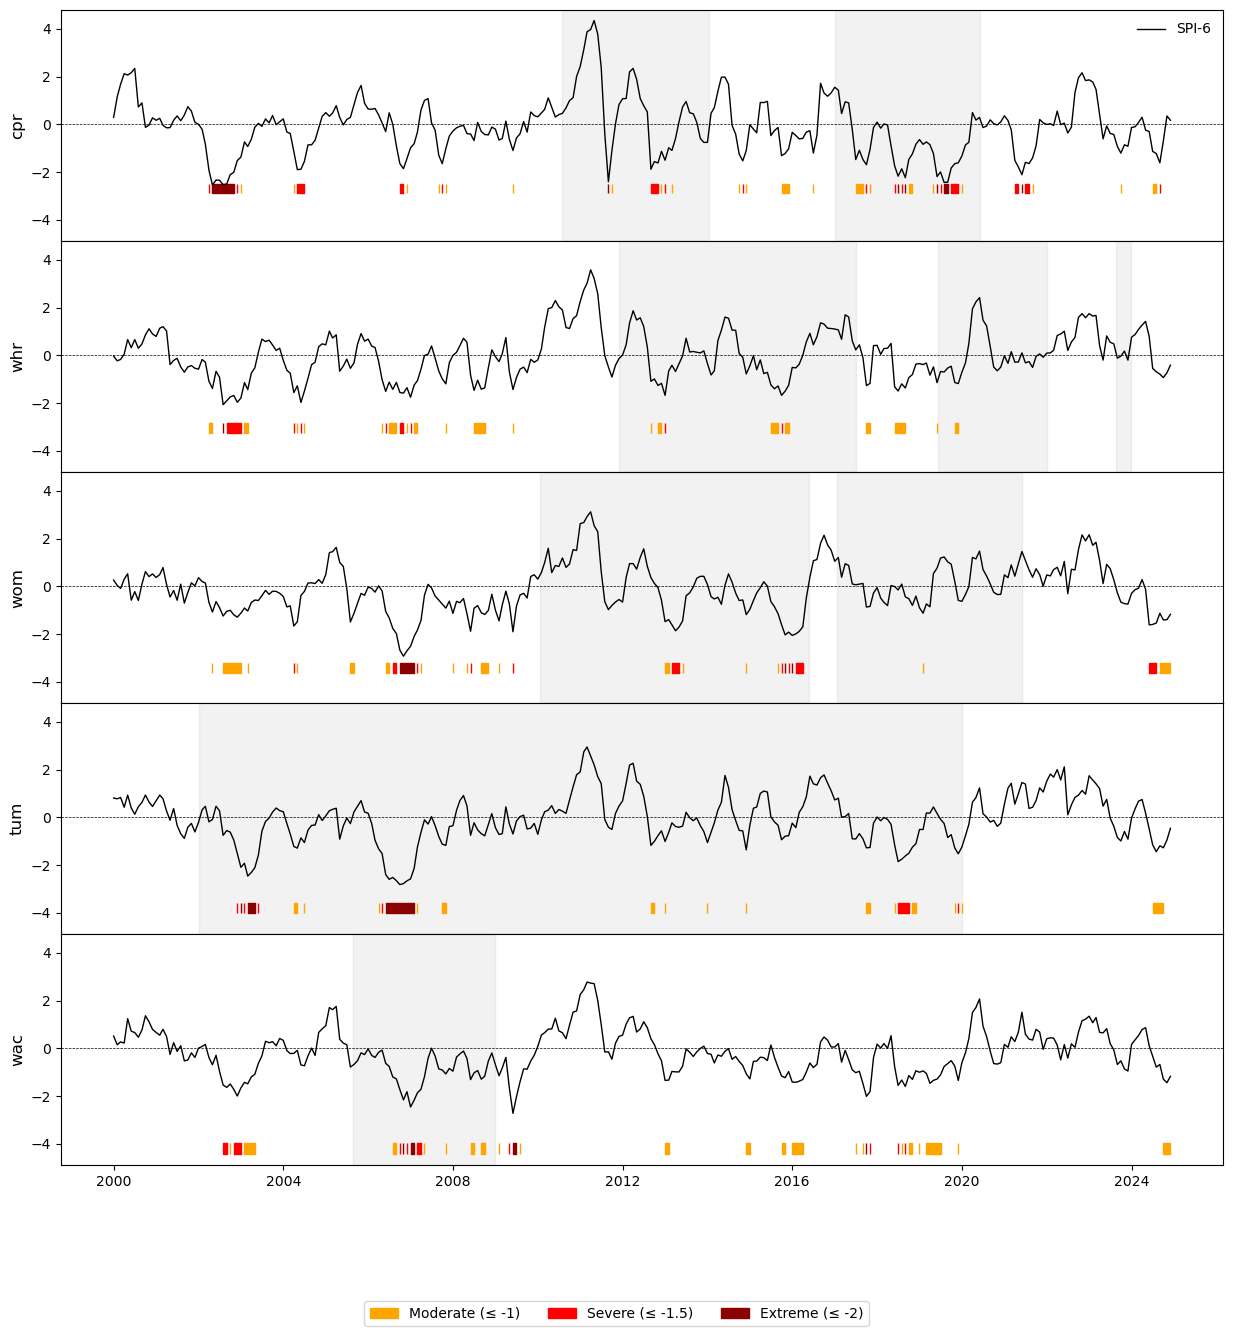

In [177]:
sites = ['cpr', 'whr', 'wom', 'tum', 'wac']

fig, axes = plt.subplots(5, 1, figsize=(15, 15), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0)


start_date = '2000-01-01'
end_date = '2024-12-31'

import matplotlib.patches as mpatches

drought_handles = [
    mpatches.Patch(color='orange', label='Moderate (≤ -1)'),
    mpatches.Patch(color='red', label='Severe (≤ -1.5)'),
    mpatches.Patch(color='darkred', label='Extreme (≤ -2)')
]


for i, site in enumerate(sites):
    drought_indices_M, drought_indices_D = load_drought_indices(site)
    spei12 = drought_indices_M['SPI_6'].loc[start_date:end_date] #should be SPEI_12
    
    dates = pd.to_datetime(date_ranges[i])
    dates = dates.sort_values()

    # difference between consecutive dates
    diff = dates.to_series().diff()

    # start of new block where gap > 1 day
    block_id = (diff > pd.Timedelta(days=1)).cumsum()

    # group into continuous periods
    periods = dates.to_series().groupby(block_id).agg(['min', 'max'])
    for _, row in periods.iterrows():
        axes[i].axvspan(row['min'], row['max'], color='gray',alpha=0.1)

    axes[i].plot(spei12.index, spei12.values, label='SPEI12', color='black', linewidth=1)

    ymin, ymax = axes[i].get_ylim()
    band_height = (ymax - ymin) * 0.05  # 5% of axis height

    band_bottom = ymin
    band_top = ymin + band_height

    # Extreme drought (≤ -2)
    axes[i].fill_between(spei12.index, band_bottom, band_top,
                where=(spei12 <= -2),
                color='darkred', step='mid')

    # Severe drought (≤ -1.5)
    axes[i].fill_between(spei12.index, band_bottom, band_top,
                where=(spei12 <= -1.5) & (spei12 > -2),
                color='red', step='mid')

    # Moderate drought (≤ -1)
    axes[i].fill_between(spei12.index, band_bottom, band_top,
                where=(spei12 <= -1) & (spei12 > -1.5),
                color='orange', step='mid')
    
    #axes[i].set_title(site, loc='right', fontsize=15)

    axes[i].axhline(0, color='black', linestyle='--', linewidth=0.5)
    axes[i].set_ylabel(site, fontsize=12)

    if i == 0:
        axes[i].legend([axes[i].lines[0]], ['SPI-6'],
                  loc='upper right',
                  frameon=False)


fig.legend(handles=drought_handles, loc='lower center', ncol=3, fontsize=10, frameon=True)



plt.savefig('drought_periods_SPI6.png', dpi=200, bbox_inches='tight')

In [163]:
monthly_path = '/Users/phelps/PhD/DATA/climate/Indices/monthly/SW_indices_M.csv'
daily_path = '/Users/phelps/PhD/DATA/climate/Indices/daily/SW_indices_D.csv'

sw_indices_M = pd.read_csv(monthly_path)
sw_indices_M['date'] = pd.to_datetime(sw_indices_M['date'])
sw_indices_M.set_index('date', inplace=True)
sw_indices_M.drop(columns=['Unnamed: 0'], inplace=True)

sw_indices_D = pd.read_csv(daily_path)
sw_indices_D['date'] = pd.to_datetime(sw_indices_D['date'])
sw_indices_D.set_index('date', inplace=True)
sw_indices_D.drop(columns=['Unnamed: 0'], inplace=True) 

drought_indices_M = load_drought_indices('wom')[0]
drought_indices_D = load_drought_indices('wom')[1]

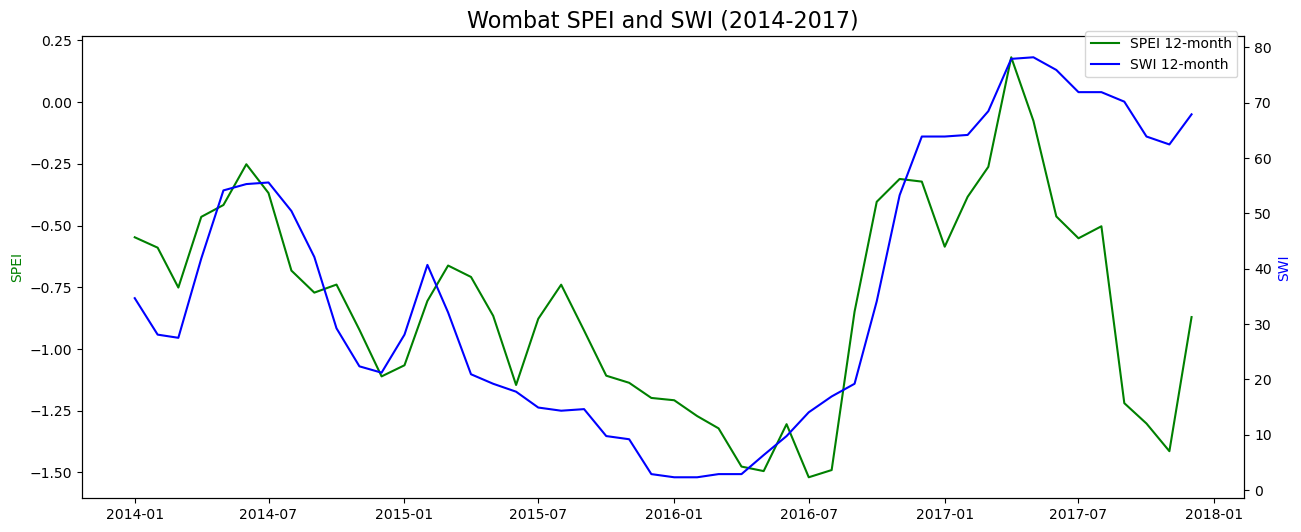

In [191]:
start_date = '2014-01-01'
end_date = '2017-12-31'


### MONTHLY INDICES

time_M = drought_indices_M.loc[start_date:end_date].index
spi6 = drought_indices_M.loc[start_date:end_date]['SPI_6']
spi12 = drought_indices_M.loc[start_date:end_date]['SPI_12']
spei6 = drought_indices_M.loc[start_date:end_date]['SPEI_6']
spei12 = drought_indices_M.loc[start_date:end_date]['SPEI_12']

ri6 = drought_indices_M.loc[start_date:end_date]['RI_6']
ri12 = drought_indices_M.loc[start_date:end_date]['RI_12']
swi12 = sw_indices_M.loc[start_date:end_date]['SWI_1_12']
swi6 = sw_indices_M.loc[start_date:end_date]['SWI_1_6']
sw_anom_M = sw_indices_M.loc[start_date:end_date]['SW_anom_M']

sw_anom_D = sw_indices_D.loc[start_date:end_date]['SW_anom']

sw_anom_D_MA = sw_anom_D.rolling(window=30, center=True).mean()

fig, ax = plt.subplots(figsize=(15, 6))
#ax.plot(time_M, spi6, label='SPI 6-month', color='orange')
ax.plot(time_M, spei12, label='SPEI 12-month', color='green')
#ax.plot(time_M, spei6, label='SPEI 6-month', color='cyan')
ax2 = ax.twinx()
#ax2.plot(time_M, ri12, label='RI 12-month', color='red')
#ax2.plot(time_M, ri6, label='RI 6-month', color='purple')
ax2.plot(time_M, swi12, label='SWI 12-month', color='blue')
#ax2.plot(time_M, swi6, label='SWI 6-month', color='orange')
#ax2.plot(time_M, sw_anom_M, label='SW monthly anom', color='blue')
#ax2.plot(sw_anom_D_MA.index, sw_anom_D_MA.values, label='SW daily anom (30-day MA)', color='cyan')

fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))

ax2.set_ylabel('SWI', color='blue')
ax.set_ylabel('SPEI', color='green')


plt.title('Wombat SPEI and SWI (2014-2017)', fontsize=16)



plt.savefig('wombat_spei_swi_2014-2017.png')




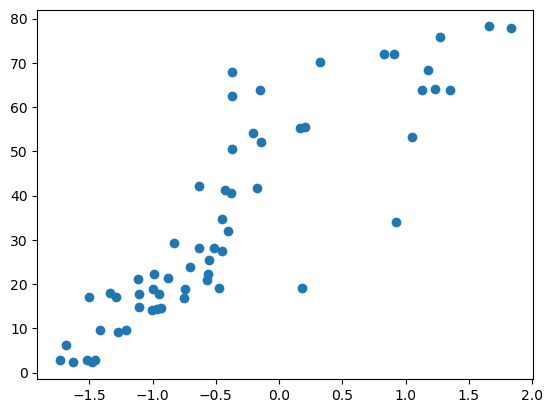

In [169]:
plt.scatter(spei12, swi12)

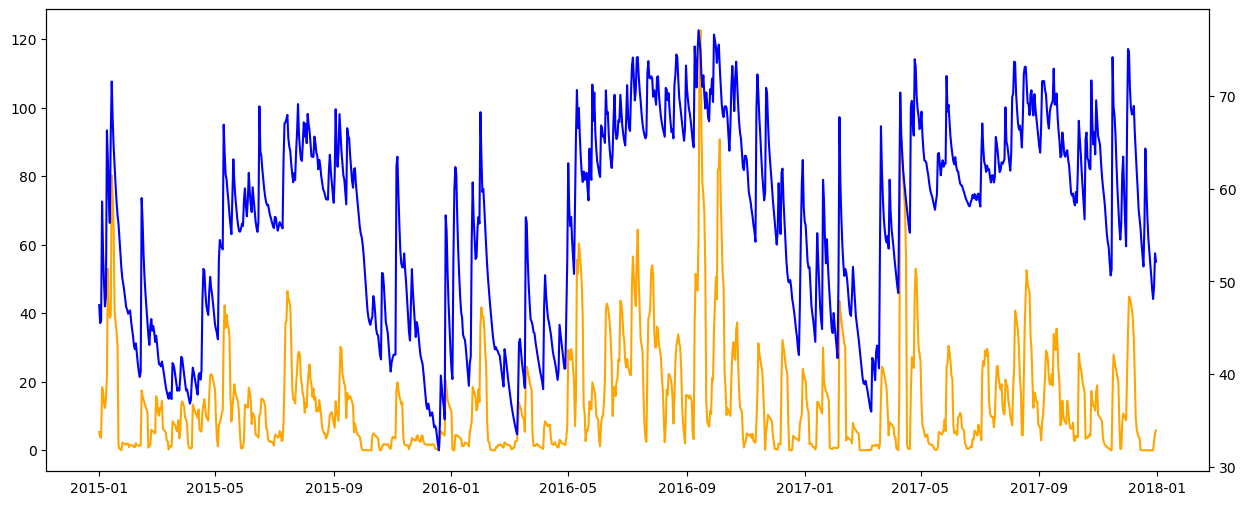

In [86]:

### DAILY INDICES

time_D = drought_indices_D.loc[start_date:end_date].index
api7 = drought_indices_D.loc[start_date:end_date]['API_7']
api30 = drought_indices_D.loc[start_date:end_date]['API_30']
ri180 = drought_indices_D.loc[start_date:end_date]['RI_180']
ri365 = drought_indices_D.loc[start_date:end_date]['RI_365']

sw = 180 * sw_indices_D.loc[start_date:end_date]['swvl1']
sw_anom_D = sw_indices_D.loc[start_date:end_date]['SW_anom']
swi180 = sw_indices_D.loc[start_date:end_date]['SWI_1_180']

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(time_D, api7, label='RI 180-day', color='orange')
    
ax2 = ax.twinx()
ax2.plot(time_D, sw, label='SW', color='blue') 
#ax2.plot(time, ri365, label='RI 365-day', color='purple')